[![View notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos-krk/ccnact/blob/main/examples/raw_state.ipynb) 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos-krk/ccnact/blob/main/examples/raw_state.ipynb) 
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos-krk/ccnact.git/main?urlpath=lab/tree/examples/raw_state.ipynb)

The code below exemplifies how to plot the saturation profile and the evolution of wet radii based on a `ccnact` simulation. 

Note that the use of `SI` below is only meant for improving code readibility and handling SI-prefix conversions, there is no dimensional analysis of the arithmetics performed (this is the default mode of operation, see [package source](https://github.com/open-atmos-krk/ccnact/blob/main/ccnact.py) for tests which employ dimensional analysis).

In [1]:
import sys

if "google.colab" in sys.modules:
    !pip --quiet install ccnact open-atmos-jupyter-utils matplotlib

In [2]:
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot

from ccnact import SI, parcel

In [3]:
_, rh, r_w, time, act = parcel(
    # updraft and initial thermodynamic state
    w=(updraft := 2 * SI.m / SI.s),
    p=1013 * SI.hPa,
    T=300 * SI.K,
    RH=0.99,
    # dry aerosol spectrum
    kappa=(1.2,),
    meanr=(3e-8 * SI.m,),
    gstdv=(1.5,),
    n_tot=(5e9 / SI.m**3,),
    # numerics
    n_bins=16,
    dt=(length_scale := 10 * SI.m) / updraft,
    nt=100 * SI.m / length_scale,
)

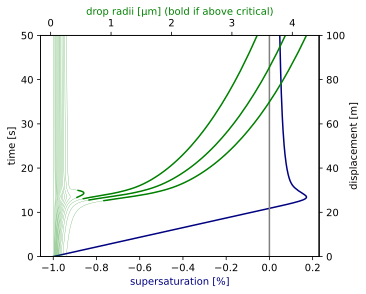

In [4]:
xy1 = pyplot.figure(figsize=(5, 4)).gca()
xy2 = xy1.twiny()
for i in range(r_w.shape[0]):
    xy2.plot(r_w[i, :] / SI.um, time, color=(r_color := "green"), lw=0.2)
    xy2.plot(np.where(act[i, :], r_w[i, :] / SI.um, np.nan), time, color=r_color)
xy1.plot((rh - 1) * 100, time, color=(s_color := "navy"))
xy1.axvline(0, color="gray")
xy1.set(ylabel="time [s]", ylim=(time[0], time[-1]))
xy1.set_xlabel("supersaturation [%]", color=s_color)
xy2.set_xlabel("drop radii [μm] (bold if above critical)", color=r_color)
xy1.secondary_yaxis(
    "right",
    functions=(
        lambda t: updraft * t,
        lambda z: z / updraft,
    ),
).set_ylabel("displacement [m]")
show_plot("raw_state")